In [2]:
import numpy as np
import random
import os
from skimage.io import imread 
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_addons as tfa
from batch_generators.BatchGeneratorTripletSemiHardLoss import BatchGenerator
from tensorflow.keras import layers, models
from keras.applications import DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from scipy.spatial import distance
import pickle
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay

In [4]:
path_images = "./images/faces_webface_112x112/imgs/"

NUM_IMGS = 1000
INPUT = (112, 112, 3)

In [5]:
data_files_train = [[path_images + str(id), id] for id in range(NUM_IMGS)]
batch_gen_train = BatchGenerator(data_files_train, batch_size=128, dim = INPUT)

data_files_val = [[path_images + str(id), id] for id in range(NUM_IMGS, NUM_IMGS + 200)]
batch_gen_val = BatchGenerator(data_files_val, batch_size=128, dim = INPUT)

In [4]:
#batch_gen_val.__getitem__(0)

## Model

In [6]:
backbone = DenseNet121(include_top = False,
                         weights = "imagenet",
                         input_shape = INPUT
                        )

for layer in backbone.layers:
    layer.trainable = False
                                            
inputs = layers.Input(shape=INPUT)

x = backbone(inputs)
x = tf.keras.layers.GlobalAveragePooling2D() (x)
dense1 = tf.keras.layers.Dense(units = 512, activation = 'relu')(x)
dense2 = tf.keras.layers.Dense(units = 256, activation = 'relu')(dense1)
outputs = tf.keras.layers.Dense(units = 256, activation = None)(dense2)

model = models.Model(inputs = inputs, outputs = outputs)

In [6]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(0.001),
    loss=tfa.losses.TripletSemiHardLoss(margin=0.5,
                                        distance_metric="angular"))

In [7]:
filepath="./models/model_semihard_realdata.keras"
checkpoint = ModelCheckpoint(filepath, 
                             monitor = 'val_loss', 
                             verbose = 1,
                             save_best_only = True, 
                             mode = 'min')

In [8]:
# Train the network
history = model.fit(
    batch_gen_train,
    validation_data=batch_gen_val,
    epochs=1000,
    callbacks=checkpoint)

Epoch 1/1000


2024-07-12 15:50:49.109742: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2024-07-12 15:50:49.114617: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2024-07-12 15:50:49.603375: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/Max_1_grad/Sum/Max_1/reduction_indices' with dtype int32
	 [[{{node gradients/Max_1_grad/Sum/Max_1/reduction_indices}}]]
2024-07-12 15:50:49.605193: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an e

7/7 [==============================] - ETA: 0s - loss: 0.4948

2024-07-12 15:50:55.029631: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]



Epoch 1: val_loss improved from inf to 0.49378, saving model to model_semihard_realdata.keras
7/7 [==============================] - 7s 801ms/step - loss: 0.4948 - val_loss: 0.4938
Epoch 2/1000
7/7 [==============================] - ETA: 0s - loss: 0.4940
Epoch 2: val_loss improved from 0.49378 to 0.49261, saving model to model_semihard_realdata.keras
7/7 [==============================] - 5s 670ms/step - loss: 0.4940 - val_loss: 0.4926
Epoch 3/1000
7/7 [==============================] - ETA: 0s - loss: 0.4923
Epoch 3: val_loss improved from 0.49261 to 0.49173, saving model to model_semihard_realdata.keras
7/7 [==============================] - 5s 675ms/step - loss: 0.4923 - val_loss: 0.4917
Epoch 4/1000
7/7 [==============================] - ETA: 0s - loss: 0.4915
Epoch 4: val_loss improved from 0.49173 to 0.48935, saving model to model_semihard_realdata.keras
7/7 [==============================] - 5s 679ms/step - loss: 0.4915 - val_loss: 0.4894
Epoch 5/1000
7/7 [====================

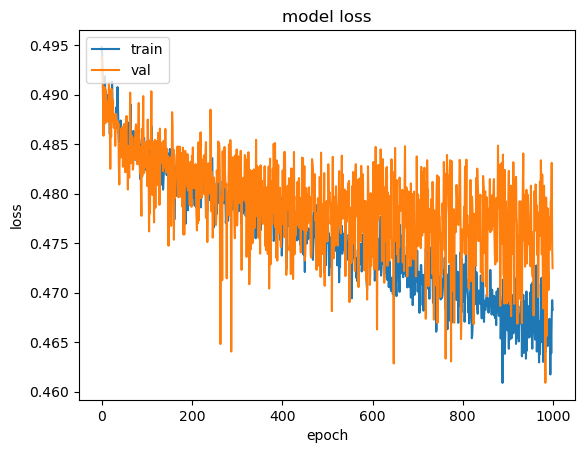

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Prediction

In [7]:
filepath = "./models/model_semihard_realdata.keras"
model.load_weights(filepath)

In [8]:
with open('test_data.pkl', 'rb') as f:
    (true_pairs, true_pairs_1_test, true_pairs_2_test, false_pairs, false_pairs_1_test, false_pairs_2_test) = pickle.load(f)

In [9]:
pred_true_pairs_1 = model.predict(true_pairs_1_test)
pred_true_pairs_2 = model.predict(true_pairs_2_test)

16/16 [==============================] - 11s 662ms/step


In [10]:
pred_false_pairs_1 = model.predict(false_pairs_1_test)
pred_false_pairs_2 = model.predict(false_pairs_2_test)

16/16 [==============================] - 11s 698ms/step


In [11]:
real_test = np.concatenate((np.ones(len(true_pairs)), np.zeros(len(false_pairs))))

true_preds = [1 - distance.cosine(pred_true_pairs_1[i], pred_true_pairs_2[i]) for i in range(len(pred_true_pairs_2))]
false_preds = [1 - distance.cosine(pred_false_pairs_1[i], pred_false_pairs_2[i]) for i in range(len(pred_false_pairs_2))]

pred_test = np.concatenate((np.asarray(true_preds), np.asarray(false_preds)))

In [12]:
def pred_threshold(predictions, thr):
    predictions = np.asarray([0. if val > thr else 1. for val in predictions])
    
    return predictions

def plt_cm_metrics(y_test, y_pred):

    print('Acuraccy: %.3f' % accuracy_score(y_test, y_pred))
    print('Precision: %.3f' % precision_score(y_test, y_pred))
    print('Recall: %.3f' % recall_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

def calc_metric(y_test, y_pred, metric):
    if metric == 'acc':
        return accuracy_score(y_test, y_pred)
        
    elif metric == 'precision':
        return precision_score(y_test, y_pred)

    elif metric == 'recall':
        return recall_score(y_test, y_pred)


def plt_metric_thr(y_test, y_pred, metric):
    threshold = np.arange(0.0, 1.0, 0.05)
    metric_thres = []
    
    for i in threshold:
        y_thrs_pred = pred_threshold(y_pred, thr = i)
        metric_thres.append(calc_metric(y_test, y_thrs_pred, metric))
    
    y = np.array(metric_thres)
     
    # Plotting the Graph
    plt.plot(threshold, y)
    plt.title("Curve plotted using the given points")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

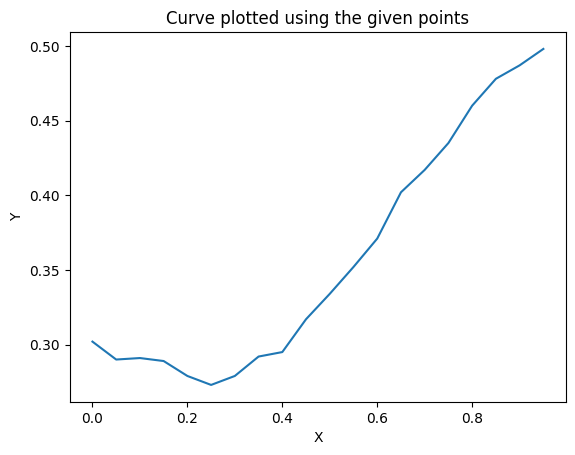

In [13]:
plt_metric_thr(real_test, pred_test, 'acc')

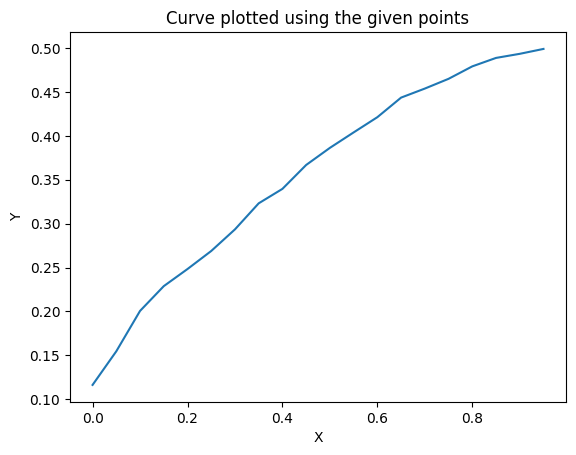

In [14]:
plt_metric_thr(real_test, pred_test, 'precision')

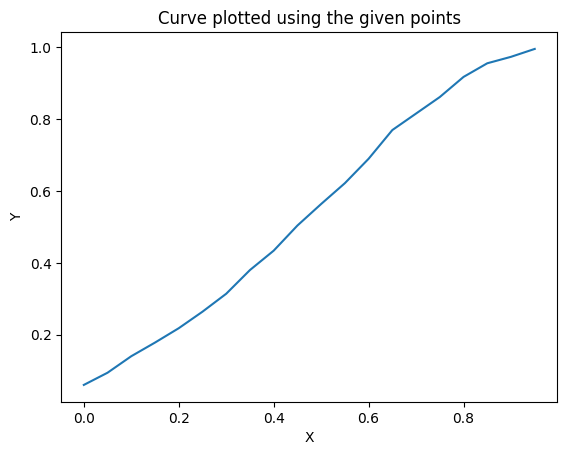

In [15]:
plt_metric_thr(real_test, pred_test, 'recall')

Acuraccy: 0.294
Precision: 0.129
Recall: 0.072


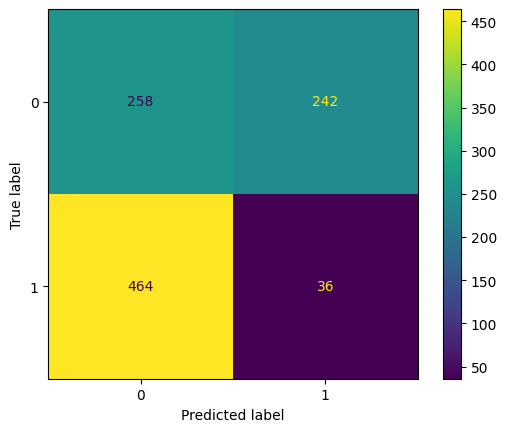

In [16]:
pred_thr_test = pred_threshold(pred_test, thr = 0.025)
plt_cm_metrics(real_test, pred_thr_test)

Acuraccy: 0.279
Precision: 0.248
Recall: 0.218


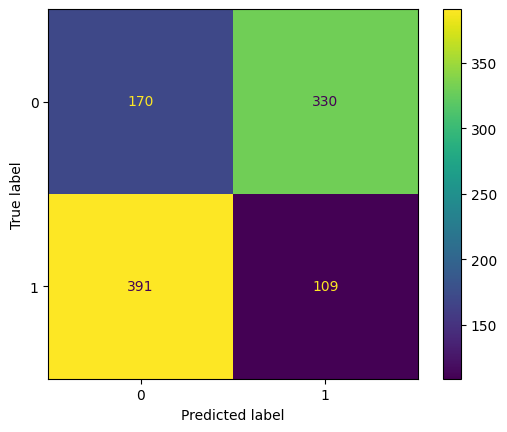

In [17]:
pred_thr_test = pred_threshold(pred_test, thr = 0.2)
plt_cm_metrics(real_test, pred_thr_test)

Acuraccy: 0.295
Precision: 0.340
Recall: 0.434


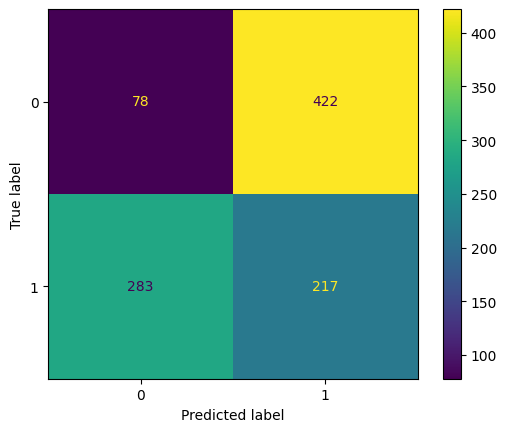

In [18]:
pred_thr_test = pred_threshold(pred_test, thr = 0.4)
plt_cm_metrics(real_test, pred_thr_test)

Acuraccy: 0.460
Precision: 0.479
Recall: 0.918


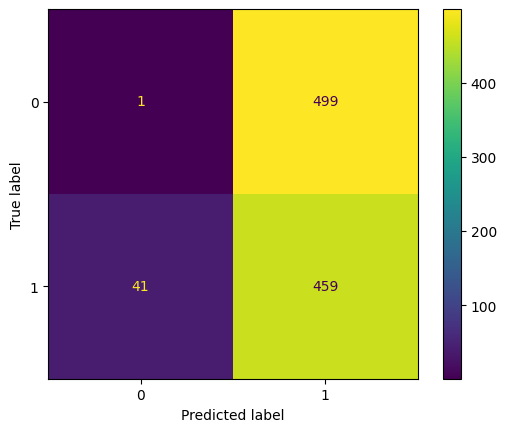

In [19]:
pred_thr_test = pred_threshold(pred_test, thr = 0.8)
plt_cm_metrics(real_test, pred_thr_test)